In [1]:
from pathlib import Path
from jax import config
import jax.numpy as np
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.lensing_utils_alt import (
    compute_lensed_angles_approx,
    get_agn_lens_angles,
    PML_time_delay_magnification, 
)
from gwfast.fisherTools import (
    reduce_Fisher_matrix, 
    plot_corners, compute_covariance_matrix, print_matrices
)

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    h1_dot_h2 = inner_product(frequencies, h1, h2, psd)
    h1_norm_sq = inner_product(frequencies, h1, h1, psd)
    h2_norm_sq = inner_product(frequencies, h2, h2, psd)
    return 1 - h1_dot_h2 / np.sqrt(h1_norm_sq * h2_norm_sq)

def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota'] = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase'] = np.zeros_like(mag_1)  # No change in phi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in phi
    return output_params


In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_Lensed = network.DetNet({'H1': H1_Lensed, 'L1': L1_Lensed, 'V1': V1_Lensed})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

In [4]:
shape = 3
lensing_parameters = {
    'Mc': 80, 'eta': 0.23, 'iota': 0.99 * np.pi / 2, 'phase': 2.1,
    'chi1z': 0.3, 'chi2z': 0.4, 'tcoal': 0.0,
    'theta': 0.1, 'phi': 0.3, 'psi': 0.3, 'dL': 2.0, 
    'R_orbit': 100, 'M_lz': 5e5, 'src_pos': 0.2
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}
lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05

agn_lensed_params = compute_lensed_angles_approx(lensing_parameters)
lensed_params = PML_simple_lens_parameters(lensing_parameters)
lensed_params['delta_time'], agn_lensed_params['delta_time'] / DAY_TO_SEC

(Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64),
 Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64))

In [5]:
sampling_frequency = 2048.  # Hz
duration = 60.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, shape), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, shape), (0,))

In [6]:
model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)

H1_strain = H1_Lensed.GWstrain(masked_freq_grid, model_parameters)
L1_strain = L1_Lensed.GWstrain(masked_freq_grid, model_parameters)
V1_strain = V1_Lensed.GWstrain(masked_freq_grid, model_parameters)

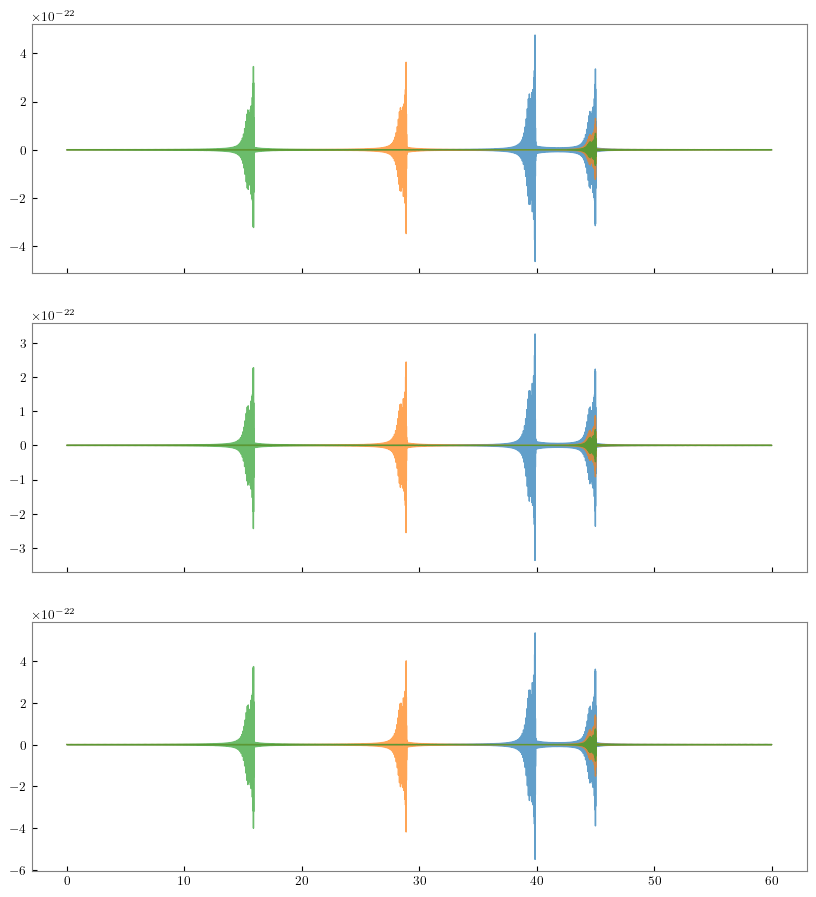

In [7]:
cplx_zeros = np.zeros((freq_array.size, shape), dtype=np.complex128)
post_merger_time = -15
n_index = int(post_merger_time * sampling_frequency)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

for ifo_strain, ax in zip((H1_strain, L1_strain, V1_strain), axes):
    # Make use of jax numpy `.at.set` copying feature
    full_strain = cplx_zeros.at[freq_mask].set(ifo_strain)

    full_TD_strain = np.fft.irfft(full_strain, axis=0) * sampling_frequency

    for idx, h1 in enumerate(full_TD_strain.T):
        ax.plot(time_array, np.roll(h1, n_index), c=f'C{idx}', label='flexible', alpha=0.7)

In [8]:
model_parameters['relative_distance']

Array([0.67715735, 0.34621048, 0.19143164], dtype=float64)

In [8]:
HLV_fisher = HLV_Lensed.FisherMatr(model_parameters, res=1000)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.86655731713929.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 17.65215266133077, Maximum duration: 32.94742119336045.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 30.640940863459154, Maximum duration: 33.02149006836768.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.86655731713929.

Warning! Some of the input parameters will likely yield waveforms with signal length longer th

In [10]:
import numpy as onp
keys = list(model_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)

print("\nThe Fisher matrices:")
print_matrices(reduce_fisher_mat, parameters=keys)
print('=================================================================')

reduced_cov_mats, ie = compute_covariance_matrix(reduce_fisher_mat)
print("\nThe Covariance matrices:")
print_matrices(reduced_cov_mats, parameters=keys)


The Fisher matrices:
                             dL                 eta                tcoal                 Mc                chi1z               theta               chi2z                phi                 iota               phase                psi              delta_iota         delta_phase      relative_distance     relative_mass         delta_time    
                dL          +8.006e+02          -5.540e+03          +6.989e-02          -1.380e+01          -4.532e+02          +1.553e+03          -1.884e+02          -9.611e+02          -9.748e-01          +1.182e-14          +1.012e+03          -6.564e+01          -3.823e+01          +1.664e+03          -2.745e+03          +1.327e+09  
               eta          -5.540e+03          +4.619e+07          +1.619e+08          -2.469e+05          +8.747e+06          +1.021e+06          +2.303e+05          +1.794e+05          +2.250e+05          -3.799e+05          -6.091e+03          +1.538e+05          -2.585e+05          -2.459e+0

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



The Covariance matrices:
                             dL                 eta                tcoal                 Mc                chi1z               theta               chi2z                phi                 iota               phase                psi              delta_iota         delta_phase      relative_distance     relative_mass         delta_time    
                dL          +1.666e-02          +1.609e-03          +2.486e-03          +1.889e-01          -4.637e-02          +3.116e-05          +9.352e-02          +4.034e-03          -2.454e-03          +1.129e-01          +2.707e-03          +1.142e-03          +1.736e-03          -1.626e-03          -2.006e-04          -6.268e-10  
               eta          +1.609e-03          +3.998e-04          +7.458e-04          +1.764e-02          -1.419e-02          -5.164e-07          +2.707e-02          -1.141e-04          +4.794e-05          +4.142e-02          -1.311e-04          -3.779e-07          -1.080e-03          +1.19

In [11]:
keys = list(model_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)
reduced_cov_mats, ie = compute_covariance_matrix(reduce_fisher_mat)

dt_idx = keys.index('delta_time')
# Convert delta_time from days to seconds
reduced_cov_mats[dt_idx, :, :] *= DAY_TO_SEC
reduced_cov_mats[:, dt_idx, :] *= DAY_TO_SEC


labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}

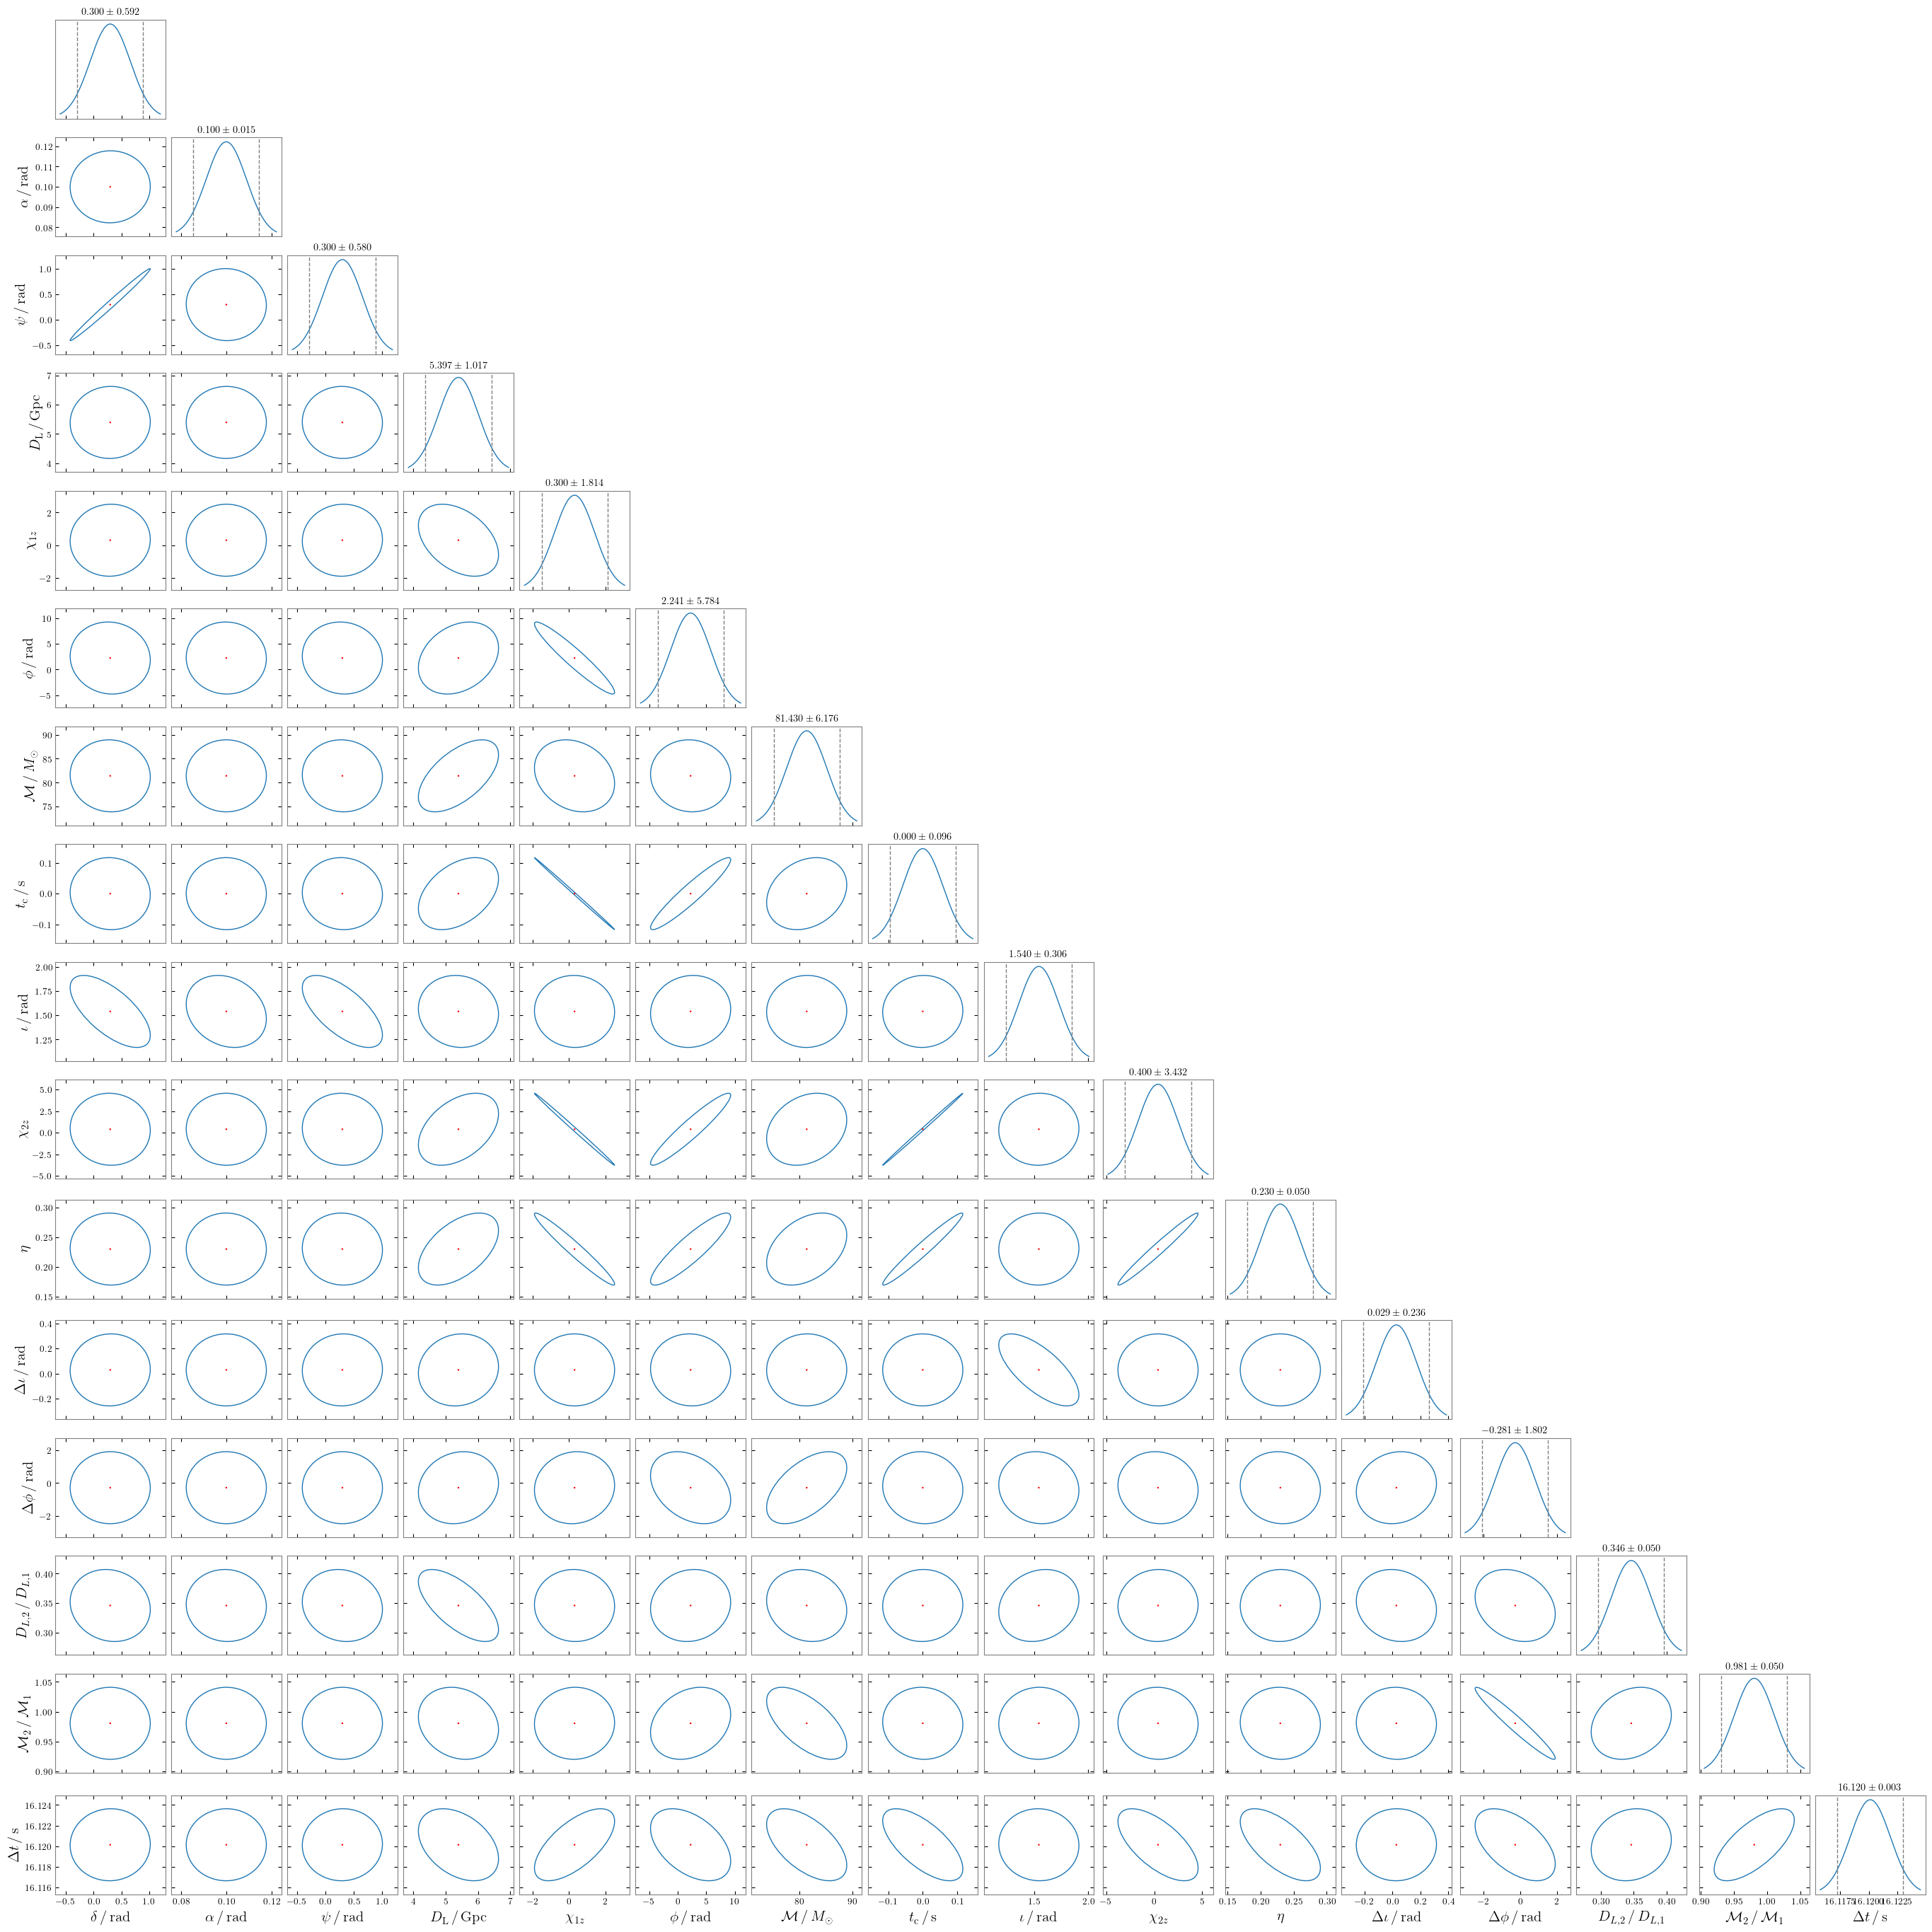

In [12]:
idx = 1
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in model_parameters.items()}
parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)

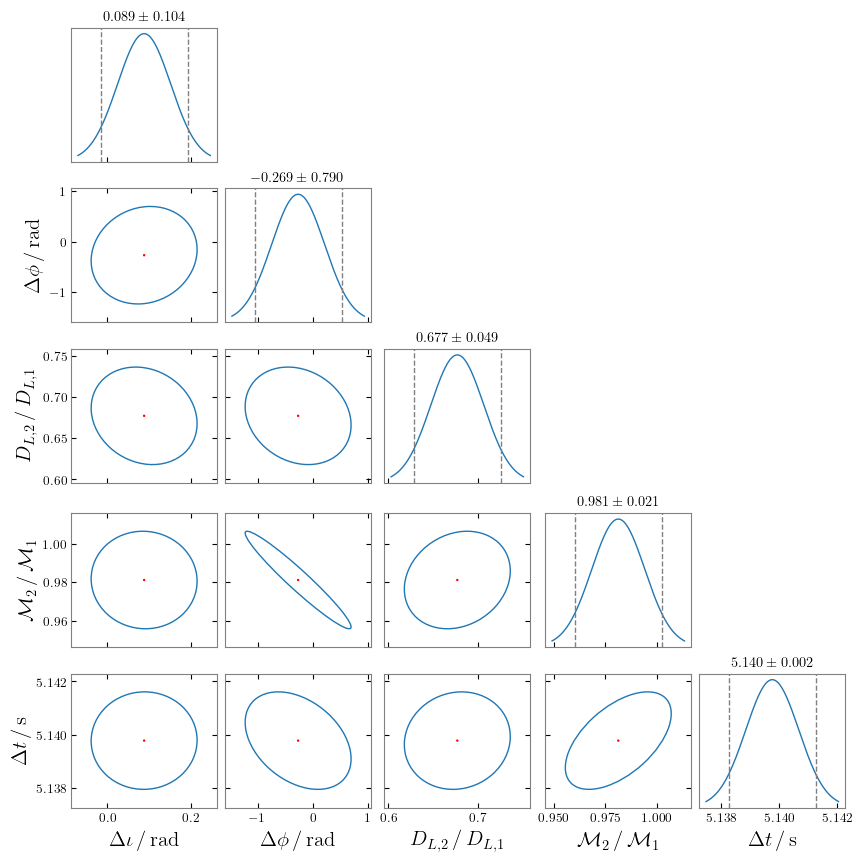

In [13]:
idx = 0
indices = np.arange(11, len(keys))
parameters = {key: val[idx] for key, val in model_parameters.items()}
parameters['delta_time'] *= DAY_TO_SEC

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys[11:], indices, 
    event=parameters, labels=labels, color='C0'
)
fig.savefig('flexible_model_Cov_sub_corner.png', dpi=300)

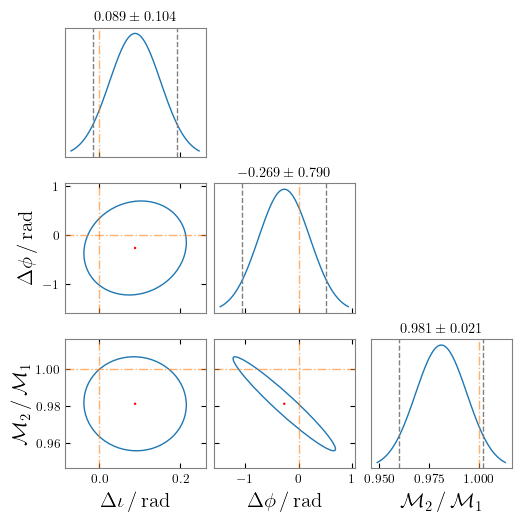

In [20]:
idx = 0
indices = [11, 12, 14]
plot_keys = [keys[i] for i in indices]
parameters = {key: val[idx] for key, val in model_parameters.items()}
parameters['delta_time'] *= DAY_TO_SEC

fig = plot_corners(
    reduced_cov_mats[:, :, idx], plot_keys, indices, 
    event=parameters, labels=labels, color='C0'
)

axes = fig.get_axes()
exp_val_kwargs = {'c': 'C1', 'ls': '-.', 'alpha': 0.6}
for idx in (0, 1, 2, 3, 4):
    axes[idx].axvline(0, **exp_val_kwargs)
axes[1].axhline(0, **exp_val_kwargs)
axes[3].axhline(1, **exp_val_kwargs)
axes[4].axhline(1, **exp_val_kwargs)
axes[5].axvline(1, **exp_val_kwargs)

fig.savefig('flexible_model_Cov_sub3_corner.pdf')

In [15]:
fig.get_axes()

[<Axes: title={'center': '$0.089 \\pm 0.104$'}>,
 <Axes: ylabel='$\\Delta \\phi\\,/\\,{\\rm rad}$'>,
 <Axes: title={'center': '$-0.269 \\pm 0.790$'}>,
 <Axes: xlabel='$\\Delta \\iota\\,/\\,{\\rm rad}$', ylabel='${\\cal M}_2 \\,/\\,{\\cal M}_1$'>,
 <Axes: xlabel='$\\Delta \\phi\\,/\\,{\\rm rad}$'>,
 <Axes: title={'center': '$0.981 \\pm 0.021$'}, xlabel='${\\cal M}_2 \\,/\\,{\\cal M}_1$'>]